In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import zipfile

# Unzip the Online Retail dataset
zip_path = "/content/online+retail.zip"
extract_path = "/content/online_retail"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Show the files that were extracted
print("Files extracted:")
print(os.listdir(extract_path))

Files extracted:
['Online Retail.xlsx']


In [3]:
# Load the Online Retail dataset
file_path = "/content/online_retail/Online Retail.xlsx"

retail = pd.read_excel(file_path)

# Display basic information
print("Dataset shape:", retail.shape)
print("\nFirst 10 rows:")
display(retail.head(10))

Dataset shape: (541909, 8)

First 10 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [4]:
# Inspect dataset structure and data quality

print("DATASET INFORMATION")
print("-" * 50)
retail.info()

print("\nMISSING VALUES")
print("-" * 50)
print(retail.isnull().sum())

print("\nDUPLICATE ROWS")
print("-" * 50)
print("Number of duplicates:", retail.duplicated().sum())

print("\nNUMERICAL SUMMARY")
print("-" * 50)
display(retail.describe())

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

MISSING VALUES
--------------------------------------------------
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country         

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
# Investigate data quality issues before cleaning

print("CANCELLED INVOICES")
print("-" * 50)

cancelled = retail[
    retail["InvoiceNo"].astype(str).str.startswith("C")
]

print("Number of cancelled transaction rows:", len(cancelled))
display(cancelled.head(10))


print("\nNEGATIVE QUANTITIES")
print("-" * 50)

negative_quantity = retail[retail["Quantity"] < 0]

print("Rows with negative quantity:", len(negative_quantity))
display(negative_quantity.head(10))


print("\nZERO OR NEGATIVE PRICES")
print("-" * 50)

invalid_price = retail[retail["UnitPrice"] <= 0]

print("Rows with zero/negative price:", len(invalid_price))
display(invalid_price.head(10))


print("\nMISSING CUSTOMER IDS")
print("-" * 50)

print("Rows missing CustomerID:", retail["CustomerID"].isna().sum())
print(
    "Percent missing:",
    round(retail["CustomerID"].isna().mean() * 100, 2),
    "%"
)

CANCELLED INVOICES
--------------------------------------------------
Number of cancelled transaction rows: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom



NEGATIVE QUANTITIES
--------------------------------------------------
Rows with negative quantity: 10624


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom



ZERO OR NEGATIVE PRICES
--------------------------------------------------
Rows with zero/negative price: 2517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom



MISSING CUSTOMER IDS
--------------------------------------------------
Rows missing CustomerID: 135080
Percent missing: 24.93 %


In [6]:
# Create a clean copy of the original dataset
clean_retail = retail.copy()

original_rows = len(clean_retail)

# 1. Remove duplicate rows
clean_retail = clean_retail.drop_duplicates()

# 2. Remove rows without CustomerID
clean_retail = clean_retail.dropna(subset=["CustomerID"])

# 3. Remove rows without product descriptions
clean_retail = clean_retail.dropna(subset=["Description"])

# 4. Remove cancelled invoices
clean_retail = clean_retail[
    ~clean_retail["InvoiceNo"].astype(str).str.startswith("C")
]

# 5. Keep only positive quantities
clean_retail = clean_retail[clean_retail["Quantity"] > 0]

# 6. Keep only positive prices
clean_retail = clean_retail[clean_retail["UnitPrice"] > 0]

# 7. Convert CustomerID from float to integer
clean_retail["CustomerID"] = clean_retail["CustomerID"].astype(int)

# Reset index
clean_retail = clean_retail.reset_index(drop=True)

# Show cleaning results
print("DATA CLEANING SUMMARY")
print("-" * 50)
print("Original rows:", original_rows)
print("Clean rows:", len(clean_retail))
print("Rows removed:", original_rows - len(clean_retail))
print(
    "Percent retained:",
    round(len(clean_retail) / original_rows * 100, 2),
    "%"
)

print("\nMissing values after cleaning:")
print(clean_retail.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_retail.duplicated().sum())

print("\nClean dataset preview:")
display(clean_retail.head(10))

DATA CLEANING SUMMARY
--------------------------------------------------
Original rows: 541909
Clean rows: 392692
Rows removed: 149217
Percent retained: 72.46 %

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows after cleaning:
0

Clean dataset preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


In [7]:
# STEP 9: FEATURE ENGINEERING

# Calculate revenue for each transaction
clean_retail["Revenue"] = (
    clean_retail["Quantity"] * clean_retail["UnitPrice"]
)

# Extract useful date/time features
clean_retail["Year"] = clean_retail["InvoiceDate"].dt.year
clean_retail["Month"] = clean_retail["InvoiceDate"].dt.month
clean_retail["Month_Name"] = clean_retail["InvoiceDate"].dt.month_name()
clean_retail["Year_Month"] = clean_retail["InvoiceDate"].dt.to_period("M").astype(str)
clean_retail["Day_of_Week"] = clean_retail["InvoiceDate"].dt.day_name()
clean_retail["Hour"] = clean_retail["InvoiceDate"].dt.hour

print("FEATURE ENGINEERING COMPLETE")
print("-" * 50)

print("Dataset shape:", clean_retail.shape)

print("\nNew columns:")
print([
    "Revenue",
    "Year",
    "Month",
    "Month_Name",
    "Year_Month",
    "Day_of_Week",
    "Hour"
])

print("\nDataset preview:")
display(clean_retail.head(10))

FEATURE ENGINEERING COMPLETE
--------------------------------------------------
Dataset shape: (392692, 15)

New columns:
['Revenue', 'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_of_Week', 'Hour']

Dataset preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_of_Week,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,8
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,8
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010,12,December,2010-12,Wednesday,8
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,2010-12,Wednesday,8
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,2010-12,Wednesday,8
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2010,12,December,2010-12,Wednesday,8


In [8]:
# STEP 10: CORE BUSINESS KPIs

# Calculate key business metrics
total_revenue = clean_retail["Revenue"].sum()

total_orders = clean_retail["InvoiceNo"].nunique()

total_customers = clean_retail["CustomerID"].nunique()

total_products_sold = clean_retail["Quantity"].sum()

unique_products = clean_retail["StockCode"].nunique()

average_order_value = total_revenue / total_orders

revenue_per_customer = total_revenue / total_customers


# Display results
print("CORE BUSINESS KPIs")
print("-" * 50)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Units Sold: {total_products_sold:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"Average Revenue per Customer: £{revenue_per_customer:,.2f}")

CORE BUSINESS KPIs
--------------------------------------------------
Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Units Sold: 5,152,002
Unique Products: 3,665
Average Order Value: £479.56
Average Revenue per Customer: £2,048.69


In [9]:
# STEP 11: MONTHLY REVENUE ANALYSIS

# Calculate revenue by month
monthly_revenue = (
    clean_retail
    .groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)

# Round revenue
monthly_revenue["Revenue"] = monthly_revenue["Revenue"].round(2)

print("MONTHLY REVENUE")
print("-" * 50)

display(monthly_revenue)

MONTHLY REVENUE
--------------------------------------------------


,Year_Month,Revenue
0,2010-12,570422.73
1,2011-01,568101.31
2,2011-02,446084.92
3,2011-03,594081.76
4,2011-04,468374.33
5,2011-05,677355.15
6,2011-06,660046.05
7,2011-07,598962.90
8,2011-08,644051.04
9,2011-09,950690.20


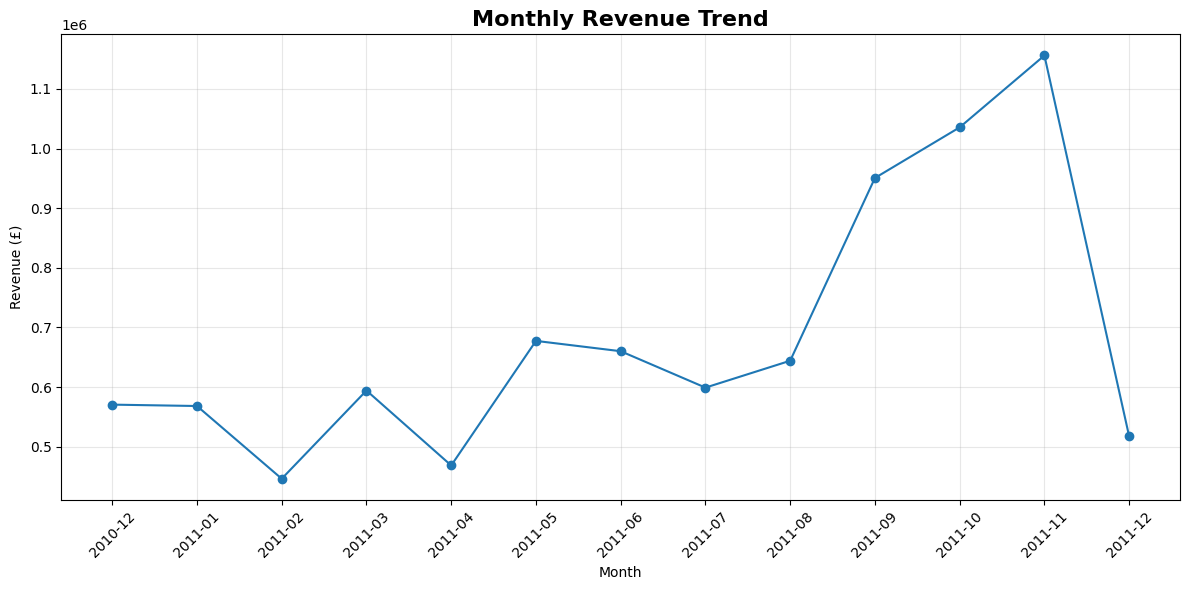

In [10]:
# STEP 12: MONTHLY REVENUE VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# STEP 13: TOP PRODUCTS BY REVENUE

top_products_revenue = (
    clean_retail
    .groupby(["StockCode", "Description"])
    .agg(
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

# Round revenue for cleaner output
top_products_revenue["Revenue"] = (
    top_products_revenue["Revenue"].round(2)
)

print("TOP 10 PRODUCTS BY REVENUE")
print("-" * 60)

display(top_products_revenue)

TOP 10 PRODUCTS BY REVENUE
------------------------------------------------------------


,StockCode,Description,Units_Sold,Revenue
2529,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1245,22423,REGENCY CAKESTAND 3 TIER,12374,142264.75
3576,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
3569,85099B,JUMBO BAG RED RETROSPOT,46078,85040.54
2027,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
3896,POST,POSTAGE,3120,77803.96
2607,47566,PARTY BUNTING,15279,68785.23
2810,84879,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
3894,M,Manual,6933,53419.93
1933,23084,RABBIT NIGHT LIGHT,27153,51251.24


In [12]:
# STEP 14: TOP PRODUCTS BY UNITS SOLD

# Exclude non-product/service entries
product_sales = clean_retail[
    ~clean_retail["StockCode"].isin(["POST", "M"])
].copy()

top_products_units = (
    product_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Units_Sold", ascending=False)
    .head(10)
)

top_products_units["Revenue"] = (
    top_products_units["Revenue"].round(2)
)

print("TOP 10 PRODUCTS BY UNITS SOLD")
print("-" * 60)

display(top_products_units)

TOP 10 PRODUCTS BY UNITS SOLD
------------------------------------------------------------


,StockCode,Description,Units_Sold,Revenue
2529,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
2027,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
2705,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,13558.41
3569,85099B,JUMBO BAG RED RETROSPOT,46078,85040.54
3576,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
2810,84879,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
359,21212,PACK OF 72 RETROSPOT CAKE CASES,33670,16381.88
1035,22197,POPCORN HOLDER,30919,23417.51
1933,23084,RABBIT NIGHT LIGHT,27153,51251.24
1310,22492,MINI PAINT SET VINTAGE,26076,16039.24


In [13]:
# STEP 15: TOP CUSTOMERS BY REVENUE

customer_summary = (
    clean_retail
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique"),
        Units_Purchased=("Quantity", "sum")
    )
    .reset_index()
)

# Calculate average order value for each customer
customer_summary["Avg_Order_Value"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Number_of_Orders"]
)

# Sort customers by total revenue
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
    .copy()
)

# Round monetary values
top_customers["Total_Revenue"] = top_customers["Total_Revenue"].round(2)
top_customers["Avg_Order_Value"] = top_customers["Avg_Order_Value"].round(2)

print("TOP 10 CUSTOMERS BY REVENUE")
print("-" * 70)

display(top_customers)

TOP 10 CUSTOMERS BY REVENUE
----------------------------------------------------------------------


,CustomerID,Total_Revenue,Number_of_Orders,Units_Purchased,Avg_Order_Value
1689,14646,280206.02,73,196915,3838.44
4201,18102,259657.30,60,64124,4327.62
3728,17450,194390.79,46,69973,4225.89
3008,16446,168472.50,2,80997,84236.25
1879,14911,143711.17,201,80240,714.98
55,12415,124914.53,21,77374,5948.31
1333,14156,117210.08,55,57768,2131.09
3771,17511,91062.38,31,64549,2937.50
2702,16029,80850.84,63,40108,1283.35
0,12346,77183.60,1,74215,77183.60


In [14]:
# STEP 16: REVENUE BY COUNTRY

country_summary = (
    clean_retail
    .groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique"),
        Number_of_Customers=("CustomerID", "nunique"),
        Units_Sold=("Quantity", "sum")
    )
    .reset_index()
)

# Calculate average order value
country_summary["Avg_Order_Value"] = (
    country_summary["Total_Revenue"] /
    country_summary["Number_of_Orders"]
)

# Sort by revenue
country_summary = country_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

# Round monetary values
country_summary["Total_Revenue"] = (
    country_summary["Total_Revenue"].round(2)
)

country_summary["Avg_Order_Value"] = (
    country_summary["Avg_Order_Value"].round(2)
)

print("TOP 10 COUNTRIES BY REVENUE")
print("-" * 70)

display(country_summary.head(10))

TOP 10 COUNTRIES BY REVENUE
----------------------------------------------------------------------


,Country,Total_Revenue,Number_of_Orders,Number_of_Customers,Units_Sold,Avg_Order_Value
35,United Kingdom,7285024.64,16646,3920,4241305,437.64
23,Netherlands,285446.34,94,9,200361,3036.66
10,EIRE,265262.46,260,3,140133,1020.24
14,Germany,228678.40,457,94,119154,500.39
13,France,208934.31,389,87,111428,537.11
0,Australia,138453.81,57,9,83891,2429.01
30,Spain,61558.56,90,30,27933,683.98
32,Switzerland,56443.95,51,21,30082,1106.74
3,Belgium,41196.34,98,25,23237,420.37
31,Sweden,38367.83,36,8,36078,1065.77


In [15]:
# STEP 17: RFM CUSTOMER ANALYSIS

# Set analysis date to one day after the final transaction
analysis_date = clean_retail["InvoiceDate"].max() + pd.Timedelta(days=1)

# Build RFM table
rfm = (
    clean_retail
    .groupby("CustomerID")
    .agg(
        Last_Purchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

# Calculate recency in days
rfm["Recency"] = (
    analysis_date - rfm["Last_Purchase"]
).dt.days

# Keep the main RFM variables
rfm = rfm[
    ["CustomerID", "Recency", "Frequency", "Monetary"]
]

# Round monetary value
rfm["Monetary"] = rfm["Monetary"].round(2)

print("RFM CUSTOMER ANALYSIS")
print("-" * 60)

print(f"Analysis date: {analysis_date.date()}")
print(f"Customers analyzed: {len(rfm):,}")

display(rfm.head(10))

RFM CUSTOMER ANALYSIS
------------------------------------------------------------
Analysis date: 2011-12-10
Customers analyzed: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [16]:
# STEP 18: RFM SCORING

# Recency: lower number of days = better score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: more orders = better score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: more spending = better score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combined RFM score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

# Total score for easier segmentation
rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

print("RFM SCORING COMPLETE")
print("-" * 60)

display(
    rfm[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score",
            "RFM_Total"
        ]
    ].head(10)
)

RFM SCORING COMPLETE
------------------------------------------------------------


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


In [17]:
# STEP 19: CUSTOMER SEGMENTATION

def assign_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 8:
        return "Potential Loyalists"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost Customers"

# Assign segment
rfm["Customer_Segment"] = rfm["RFM_Total"].apply(assign_segment)

# Create segment summary
segment_summary = (
    rfm
    .groupby("Customer_Segment")
    .agg(
        Number_of_Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Customer_Value=("Monetary", "mean")
    )
    .reset_index()
)

# Calculate percentage of customers
segment_summary["Percent_of_Customers"] = (
    segment_summary["Number_of_Customers"] / len(rfm) * 100
)

# Round results
segment_summary["Avg_Recency"] = segment_summary["Avg_Recency"].round(1)
segment_summary["Avg_Frequency"] = segment_summary["Avg_Frequency"].round(1)
segment_summary["Total_Revenue"] = segment_summary["Total_Revenue"].round(2)
segment_summary["Avg_Customer_Value"] = segment_summary["Avg_Customer_Value"].round(2)
segment_summary["Percent_of_Customers"] = segment_summary["Percent_of_Customers"].round(2)

# Sort from highest-value segment downward
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Lost Customers"
]

segment_summary["Customer_Segment"] = pd.Categorical(
    segment_summary["Customer_Segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = segment_summary.sort_values("Customer_Segment")

print("CUSTOMER SEGMENTATION SUMMARY")
print("-" * 80)

display(segment_summary)

CUSTOMER SEGMENTATION SUMMARY
--------------------------------------------------------------------------------


,Customer_Segment,Number_of_Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Customer_Value,Percent_of_Customers
1,Champions,929,14.5,11.8,6229304.44,6705.39,21.42
3,Loyal Customers,1012,43.3,3.9,1412579.34,1395.83,23.33
4,Potential Loyalists,704,79.0,2.2,610441.70,867.10,16.23
0,At Risk,808,111.7,1.5,432825.89,535.68,18.63
2,Lost Customers,885,224.0,1.0,202057.52,228.31,20.40


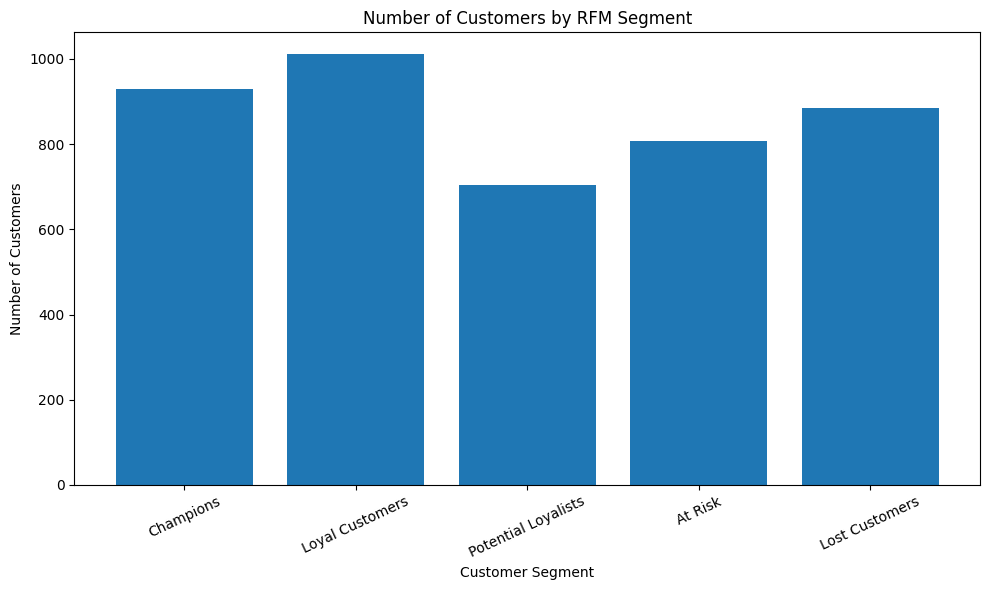

In [18]:
# STEP 20: VISUALIZE CUSTOMER SEGMENTS

import matplotlib.pyplot as plt

# Make sure segment summary follows our desired order
plot_data = segment_summary.copy()

# Customer count by segment
plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["Customer_Segment"].astype(str),
    plot_data["Number_of_Customers"]
)

plt.title("Number of Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

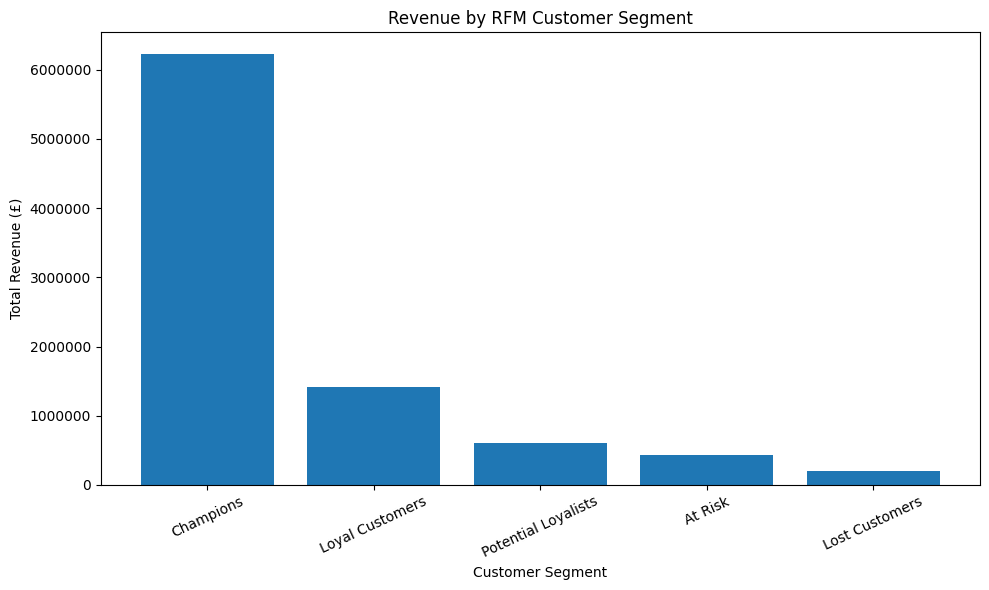

In [19]:
# STEP 21: REVENUE BY CUSTOMER SEGMENT

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Customer_Segment"].astype(str),
    segment_summary["Total_Revenue"]
)

plt.title("Revenue by RFM Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=25)

# Format y-axis as currency
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

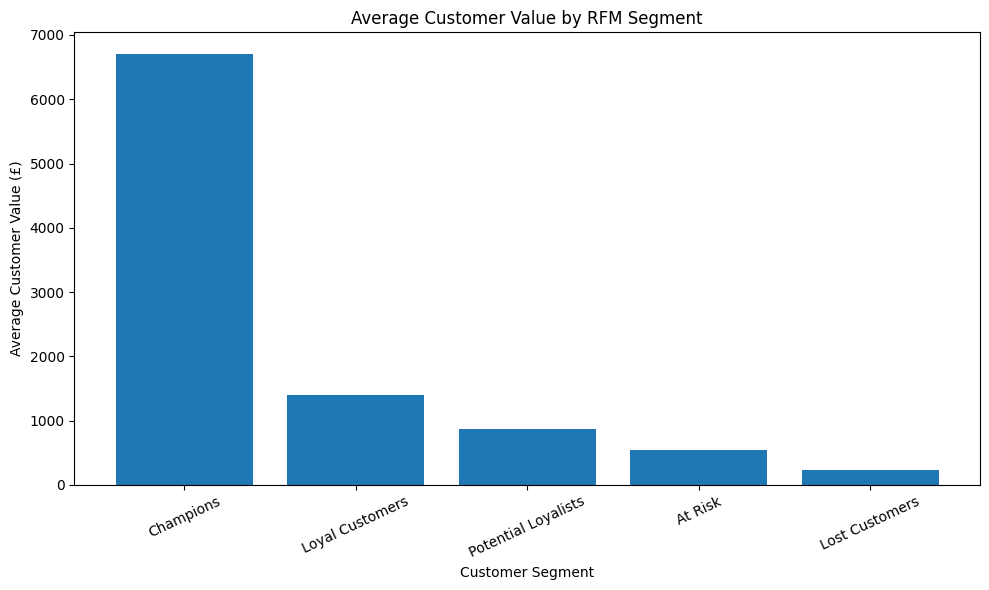

In [20]:
# STEP 22: AVERAGE CUSTOMER VALUE BY SEGMENT

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Customer_Segment"].astype(str),
    segment_summary["Avg_Customer_Value"]
)

plt.title("Average Customer Value by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Customer Value (£)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

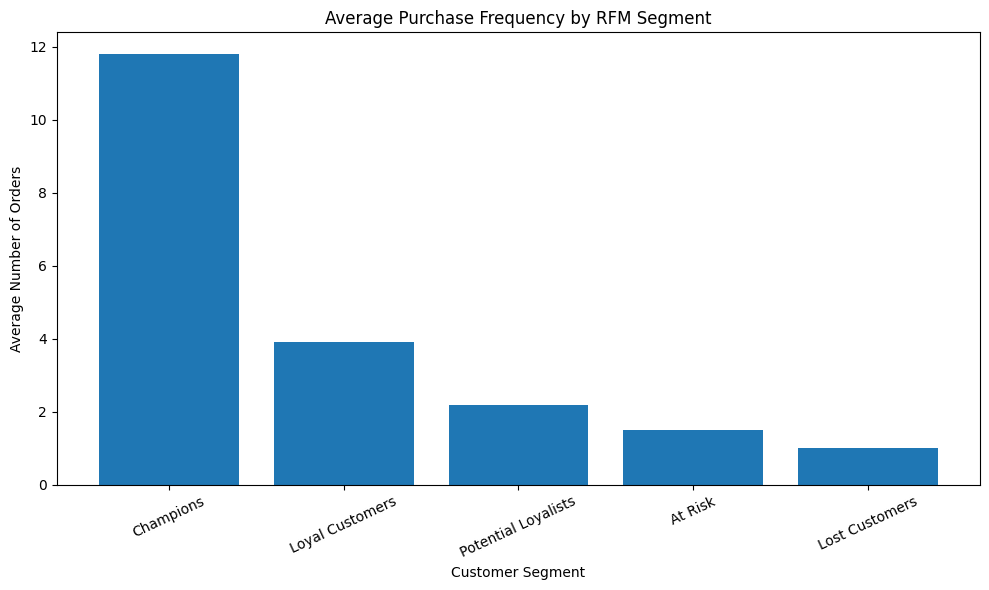

In [21]:
# STEP 23: AVERAGE PURCHASE FREQUENCY BY CUSTOMER SEGMENT

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Customer_Segment"].astype(str),
    segment_summary["Avg_Frequency"]
)

plt.title("Average Purchase Frequency by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [24]:
# STEP 24: CUSTOMER REVENUE CONCENTRATION ANALYSIS

# Create customer revenue table using the RFM dataset
customer_revenue = rfm[["CustomerID", "Monetary"]].copy()

# Rename Monetary to Revenue for clarity
customer_revenue = customer_revenue.rename(
    columns={"Monetary": "Revenue"}
)

# Sort customers from highest to lowest revenue
customer_revenue = customer_revenue.sort_values(
    "Revenue", ascending=False
).reset_index(drop=True)

# Calculate cumulative revenue
customer_revenue["Cumulative_Revenue"] = (
    customer_revenue["Revenue"].cumsum()
)

# Calculate cumulative percentage of total revenue
customer_revenue["Cumulative_Revenue_Percent"] = (
    customer_revenue["Cumulative_Revenue"]
    / customer_revenue["Revenue"].sum()
    * 100
)

# Calculate percentage of customers
customer_revenue["Customer_Percent"] = (
    (customer_revenue.index + 1)
    / len(customer_revenue)
    * 100
)

# Calculate revenue concentration
top_10 = customer_revenue.loc[
    customer_revenue["Customer_Percent"] <= 10,
    "Revenue"
].sum() / customer_revenue["Revenue"].sum() * 100

top_20 = customer_revenue.loc[
    customer_revenue["Customer_Percent"] <= 20,
    "Revenue"
].sum() / customer_revenue["Revenue"].sum() * 100

top_50 = customer_revenue.loc[
    customer_revenue["Customer_Percent"] <= 50,
    "Revenue"
].sum() / customer_revenue["Revenue"].sum() * 100

# Display results
print("CUSTOMER REVENUE CONCENTRATION")
print("-" * 50)
print(f"Total customers analyzed: {len(customer_revenue):,}")
print(f"Top 10% of customers generate: {top_10:.2f}% of revenue")
print(f"Top 20% of customers generate: {top_20:.2f}% of revenue")
print(f"Top 50% of customers generate: {top_50:.2f}% of revenue")

print("\nTop 10 customers by revenue:")
display(customer_revenue.head(10))

CUSTOMER REVENUE CONCENTRATION
--------------------------------------------------
Total customers analyzed: 4,338
Top 10% of customers generate: 61.41% of revenue
Top 20% of customers generate: 74.66% of revenue
Top 50% of customers generate: 92.19% of revenue

Top 10 customers by revenue:


,CustomerID,Revenue,Cumulative_Revenue,Cumulative_Revenue_Percent,Customer_Percent
0,14646,280206.02,280206.02,3.152914,0.023052
1,18102,259657.30,539863.32,6.074610,0.046104
2,17450,194390.79,734254.11,8.261920,0.069156
3,16446,168472.50,902726.61,10.157594,0.092208
4,14911,143711.17,1046437.78,11.774650,0.115260
5,12415,124914.53,1171352.31,13.180205,0.138313
6,14156,117210.08,1288562.39,14.499067,0.161365
7,17511,91062.38,1379624.77,15.523713,0.184417
8,16029,80850.84,1460475.61,16.433457,0.207469
9,12346,77183.60,1537659.21,17.301936,0.230521


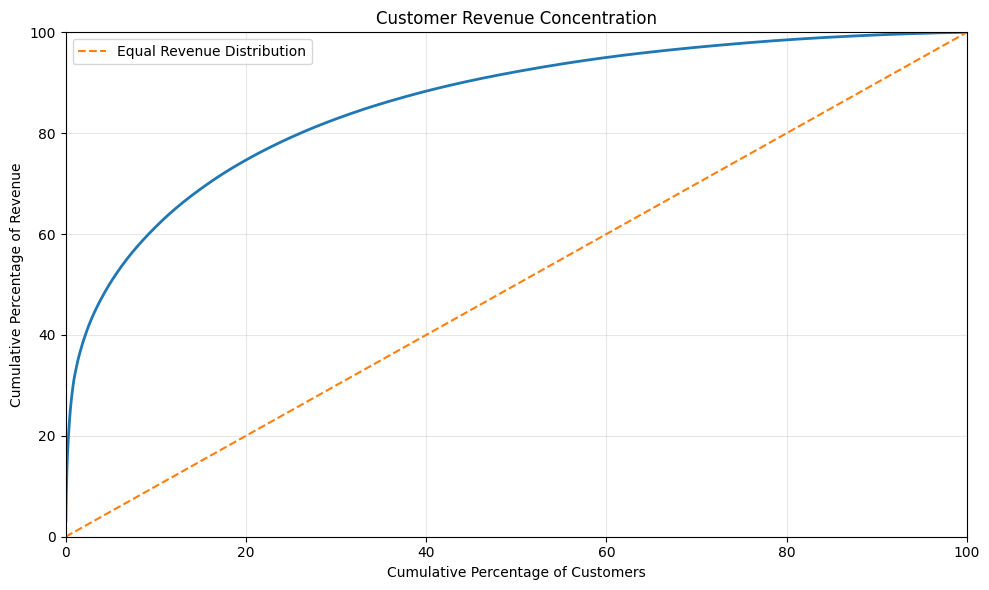

In [25]:
# STEP 25: CUSTOMER REVENUE CONCENTRATION CURVE

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    customer_revenue["Customer_Percent"],
    customer_revenue["Cumulative_Revenue_Percent"],
    linewidth=2
)

# Add reference line showing equal revenue distribution
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Equal Revenue Distribution"
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Revenue")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# STEP 26: CUSTOMER PURCHASE BEHAVIOR ANALYSIS

# Use the existing RFM customer-level dataset
customer_behavior = rfm[[
    "CustomerID",
    "Frequency",
    "Monetary"
]].copy()

# Rename columns for clearer business interpretation
customer_behavior = customer_behavior.rename(columns={
    "Frequency": "Number_of_Orders",
    "Monetary": "Total_Revenue"
})

# Calculate average order value
customer_behavior["Avg_Order_Value"] = (
    customer_behavior["Total_Revenue"] /
    customer_behavior["Number_of_Orders"]
)

print("CUSTOMER PURCHASE BEHAVIOR")
print("-" * 55)

print(f"Total customers analyzed: {len(customer_behavior):,}")

print(
    f"Average orders per customer: "
    f"{customer_behavior['Number_of_Orders'].mean():.2f}"
)

print(
    f"Median orders per customer: "
    f"{customer_behavior['Number_of_Orders'].median():.0f}"
)

print(
    f"Average customer revenue: "
    f"£{customer_behavior['Total_Revenue'].mean():,.2f}"
)

print(
    f"Median customer revenue: "
    f"£{customer_behavior['Total_Revenue'].median():,.2f}"
)

print(
    f"Average order value: "
    f"£{customer_behavior['Avg_Order_Value'].mean():,.2f}"
)

print("\nTop 10 customers by revenue:")

display(
    customer_behavior
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

CUSTOMER PURCHASE BEHAVIOR
-------------------------------------------------------
Total customers analyzed: 4,338
Average orders per customer: 4.27
Median orders per customer: 2
Average customer revenue: £2,048.69
Median customer revenue: £668.57
Average order value: £417.65

Top 10 customers by revenue:


,CustomerID,Number_of_Orders,Total_Revenue,Avg_Order_Value
1689,14646,73,280206.02,3838.438630
4201,18102,60,259657.30,4327.621667
3728,17450,46,194390.79,4225.886739
3008,16446,2,168472.50,84236.250000
1879,14911,201,143711.17,714.980945
55,12415,21,124914.53,5948.310952
1333,14156,55,117210.08,2131.092364
3771,17511,31,91062.38,2937.496129
2702,16029,63,80850.84,1283.346667
0,12346,1,77183.60,77183.600000


In [28]:
# STEP 27: REPEAT PURCHASE & CUSTOMER RETENTION ANALYSIS

# Classify customers as one-time or repeat customers
customer_behavior["Customer_Type"] = customer_behavior["Number_of_Orders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

# Count customers
customer_type_counts = (
    customer_behavior["Customer_Type"]
    .value_counts()
    .reset_index()
)

customer_type_counts.columns = ["Customer_Type", "Number_of_Customers"]

# Calculate percentage of customers
customer_type_counts["Percentage"] = (
    customer_type_counts["Number_of_Customers"]
    / len(customer_behavior)
    * 100
)

# Calculate revenue by customer type
customer_type_revenue = (
    customer_behavior
    .groupby("Customer_Type")["Total_Revenue"]
    .sum()
    .reset_index()
)

customer_type_revenue.columns = ["Customer_Type", "Total_Revenue"]

# Merge results
repeat_purchase_summary = customer_type_counts.merge(
    customer_type_revenue,
    on="Customer_Type"
)

# Calculate percentage of total revenue
repeat_purchase_summary["Revenue_Percentage"] = (
    repeat_purchase_summary["Total_Revenue"]
    / customer_behavior["Total_Revenue"].sum()
    * 100
)

# Round values
repeat_purchase_summary["Percentage"] = (
    repeat_purchase_summary["Percentage"].round(2)
)

repeat_purchase_summary["Total_Revenue"] = (
    repeat_purchase_summary["Total_Revenue"].round(2)
)

repeat_purchase_summary["Revenue_Percentage"] = (
    repeat_purchase_summary["Revenue_Percentage"].round(2)
)

print("REPEAT PURCHASE ANALYSIS")
print("-" * 60)

display(repeat_purchase_summary)

# Overall repeat purchase rate
repeat_customers = (
    customer_behavior["Number_of_Orders"] > 1
).sum()

repeat_purchase_rate = (
    repeat_customers / len(customer_behavior) * 100
)

print(f"\nTotal Customers: {len(customer_behavior):,}")
print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")

REPEAT PURCHASE ANALYSIS
------------------------------------------------------------


,Customer_Type,Number_of_Customers,Percentage,Total_Revenue,Revenue_Percentage
0,Repeat Customer,2845,65.58,8273219.33,93.09
1,One-Time Customer,1493,34.42,613989.56,6.91



Total Customers: 4,338
Repeat Customers: 2,845
Repeat Purchase Rate: 65.58%


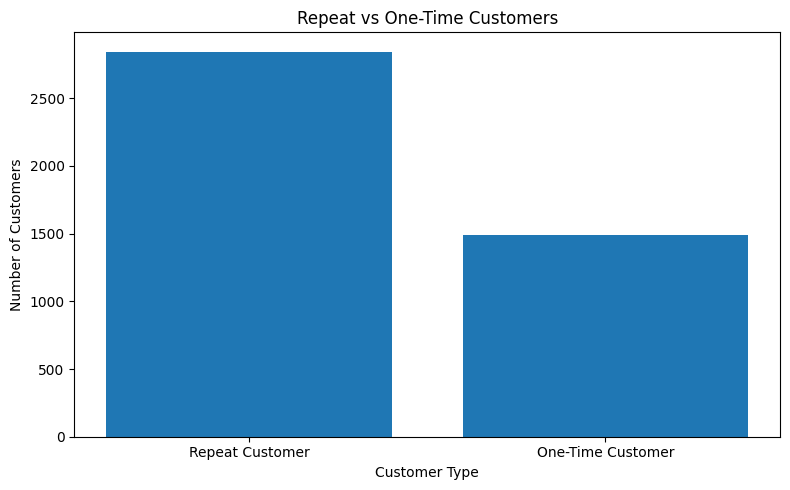

In [29]:
# STEP 28: VISUALIZE REPEAT PURCHASE BEHAVIOR

import matplotlib.pyplot as plt

# Customer count comparison
plt.figure(figsize=(8, 5))

plt.bar(
    repeat_purchase_summary["Customer_Type"],
    repeat_purchase_summary["Number_of_Customers"]
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

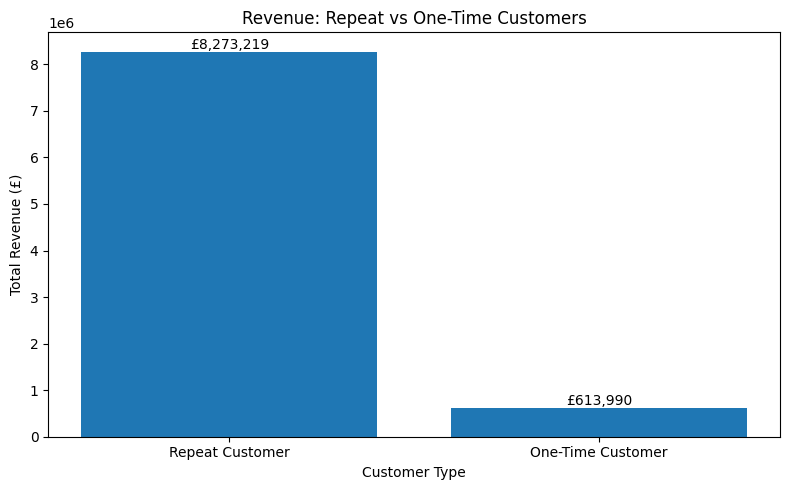

In [30]:
# STEP 29: REVENUE BY CUSTOMER TYPE

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    repeat_purchase_summary["Customer_Type"],
    repeat_purchase_summary["Total_Revenue"]
)

plt.title("Revenue: Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue (£)")

# Add revenue labels above bars
for i, value in enumerate(repeat_purchase_summary["Total_Revenue"]):
    plt.text(
        i,
        value,
        f"£{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [31]:
# STEP 30 CHECK: FIND TRANSACTION DATAFRAME

for name in ["df", "df_clean", "data", "clean_data", "retail", "retail_clean"]:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, "columns"):
            print(f"{name}: {obj.shape}")
            print(list(obj.columns))
            print()

retail: (541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']



SALES BY DAY OF WEEK
--------------------------------------------------


,Day_of_Week,Revenue
0,Monday,1363604.40
1,Tuesday,1697733.80
2,Wednesday,1584283.83
3,Thursday,1973015.73
4,Friday,1483080.81
5,Sunday,785490.32


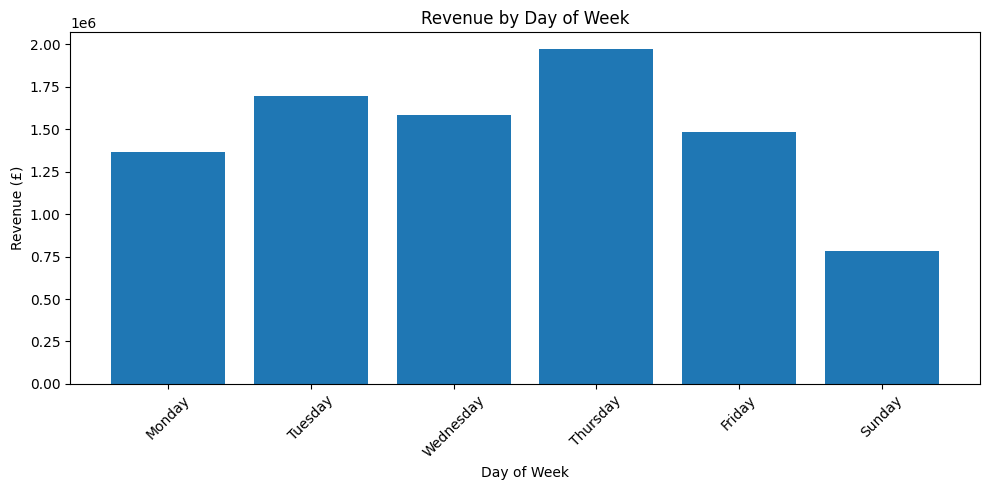

In [32]:
# STEP 30: SALES BY DAY OF WEEK

import pandas as pd
import matplotlib.pyplot as plt

# Create a fresh copy of the original data
analysis_df = retail.copy()

# Convert InvoiceDate to datetime
analysis_df["InvoiceDate"] = pd.to_datetime(
    analysis_df["InvoiceDate"],
    errors="coerce"
)

# Apply cleaning rules
analysis_df = analysis_df.dropna(
    subset=[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
)

# Keep valid positive sales only
analysis_df = analysis_df[
    (analysis_df["Quantity"] > 0) &
    (analysis_df["UnitPrice"] > 0)
].copy()

# Remove duplicate transactions
analysis_df = analysis_df.drop_duplicates()

# Create revenue
analysis_df["Revenue"] = (
    analysis_df["Quantity"] *
    analysis_df["UnitPrice"]
)

# Create day-of-week feature
analysis_df["Day_of_Week"] = analysis_df["InvoiceDate"].dt.day_name()

# Set logical weekday order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate revenue by day
daily_sales = (
    analysis_df
    .groupby("Day_of_Week")["Revenue"]
    .sum()
    .reindex(day_order)
    .dropna()
    .reset_index()
)

daily_sales["Revenue"] = daily_sales["Revenue"].round(2)

print("SALES BY DAY OF WEEK")
print("-" * 50)

display(daily_sales)

# Visualization
plt.figure(figsize=(10, 5))

plt.bar(
    daily_sales["Day_of_Week"],
    daily_sales["Revenue"]
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
print("Rows:", len(analysis_df))
print("Total Revenue:", round(analysis_df["Revenue"].sum(), 2))

Rows: 392692
Total Revenue: 8887208.89


HOURLY SALES ANALYSIS
------------------------------------------------------------


,Hour,Revenue,Transactions
0,6,4.25,1
1,7,31059.21,379
2,8,281997.79,8687
3,9,842392.34,21927
4,10,1259267.59,37773
5,11,1101177.60,48365
6,12,1373695.39,70938
7,13,1168724.20,63019
8,14,991992.82,53251
9,15,963559.68,44790



Peak revenue hour:
12:00 - £1,373,695.39


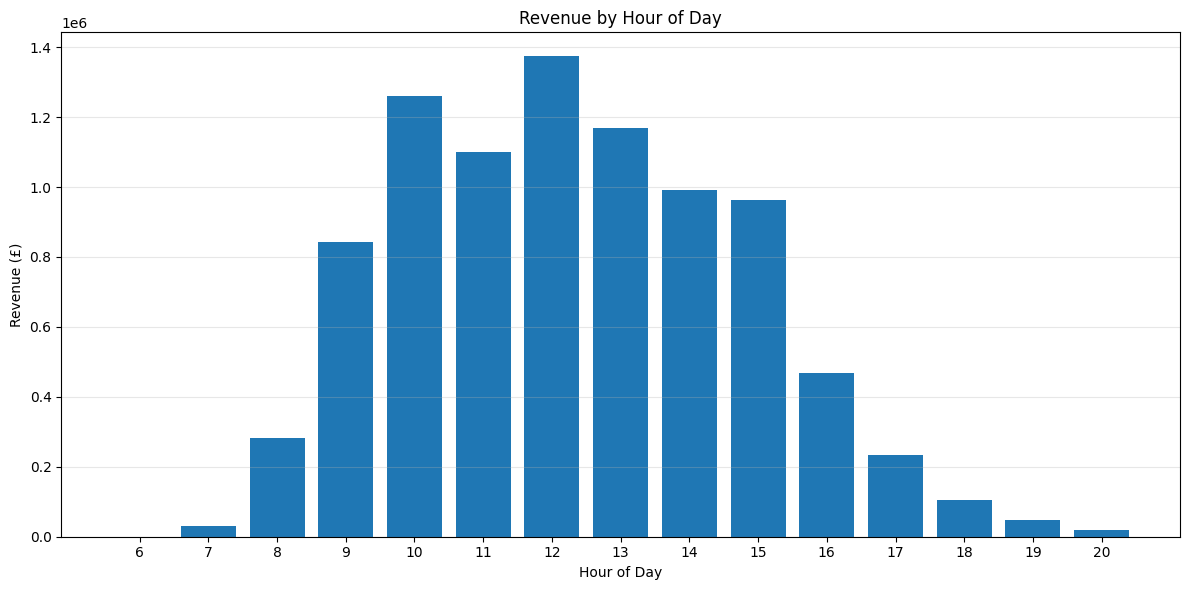

In [34]:
# STEP 31: HOURLY SALES ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt

# Make sure InvoiceDate is datetime
analysis_df["InvoiceDate"] = pd.to_datetime(analysis_df["InvoiceDate"])

# Extract hour
analysis_df["Hour"] = analysis_df["InvoiceDate"].dt.hour

# Revenue by hour
hourly_sales = (
    analysis_df.groupby("Hour")["Revenue"]
    .agg(["sum", "count"])
    .reset_index()
)

hourly_sales.columns = ["Hour", "Revenue", "Transactions"]

# Round revenue
hourly_sales["Revenue"] = hourly_sales["Revenue"].round(2)

print("HOURLY SALES ANALYSIS")
print("-" * 60)
display(hourly_sales)

# Find peak revenue hour
peak_hour = hourly_sales.loc[hourly_sales["Revenue"].idxmax()]

print("\nPeak revenue hour:")
print(
    f"{int(peak_hour['Hour']):02d}:00 - "
    f"£{peak_hour['Revenue']:,.2f}"
)

# Plot revenue by hour
plt.figure(figsize=(12, 6))

plt.bar(
    hourly_sales["Hour"],
    hourly_sales["Revenue"]
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.xticks(hourly_sales["Hour"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

MONTH-OVER-MONTH REVENUE GROWTH
------------------------------------------------------------


,Year_Month,Revenue,MoM_Growth_Percent
0,2010-12,570422.73,NaN
1,2011-01,568101.31,-0.41
2,2011-02,446084.92,-21.48
3,2011-03,594081.76,33.18
4,2011-04,468374.33,-21.16
5,2011-05,677355.15,44.62
6,2011-06,660046.05,-2.56
7,2011-07,598962.90,-9.25
8,2011-08,644051.04,7.53
9,2011-09,950690.20,47.61



Strongest month-over-month growth:
2011-09 — 47.61%

Largest month-over-month decline:
2011-12 — -55.27%


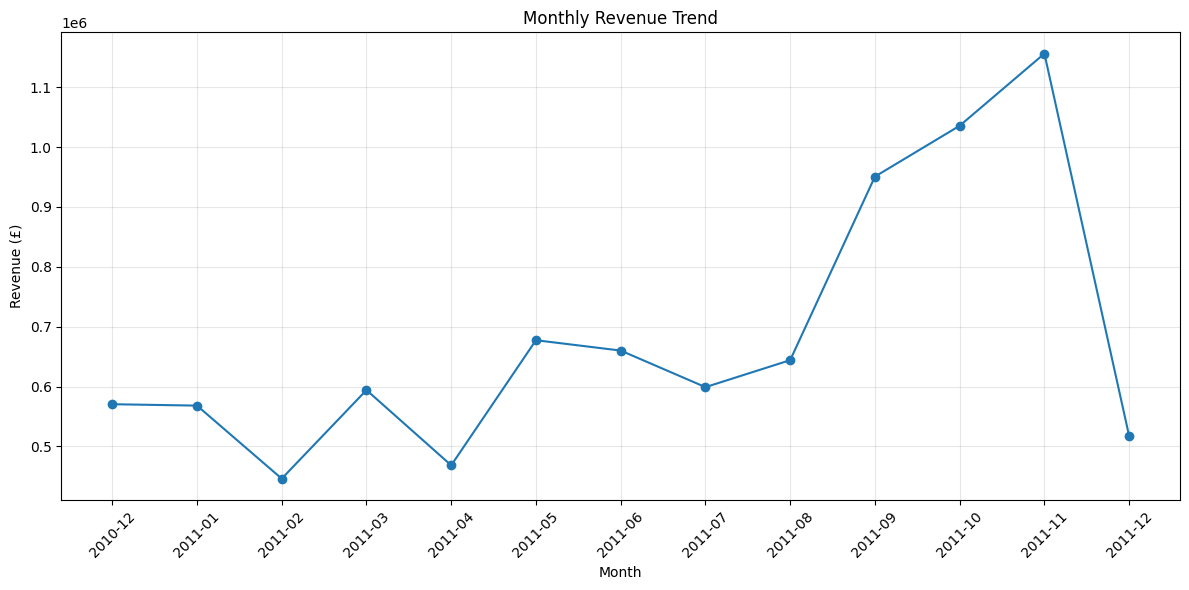

In [35]:
# STEP 32: MONTH-OVER-MONTH REVENUE GROWTH

import pandas as pd
import matplotlib.pyplot as plt

# Make sure InvoiceDate is datetime
analysis_df["InvoiceDate"] = pd.to_datetime(analysis_df["InvoiceDate"])

# Create Year-Month column
analysis_df["Year_Month"] = analysis_df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue
monthly_growth = (
    analysis_df.groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)

# Convert Year_Month to string for cleaner display
monthly_growth["Year_Month"] = monthly_growth["Year_Month"].astype(str)

# Calculate month-over-month revenue growth
monthly_growth["MoM_Growth_Percent"] = (
    monthly_growth["Revenue"]
    .pct_change() * 100
)

# Round values
monthly_growth["Revenue"] = monthly_growth["Revenue"].round(2)
monthly_growth["MoM_Growth_Percent"] = (
    monthly_growth["MoM_Growth_Percent"].round(2)
)

print("MONTH-OVER-MONTH REVENUE GROWTH")
print("-" * 60)

display(monthly_growth)

# Find strongest growth month
valid_growth = monthly_growth.dropna(
    subset=["MoM_Growth_Percent"]
)

best_month = valid_growth.loc[
    valid_growth["MoM_Growth_Percent"].idxmax()
]

worst_month = valid_growth.loc[
    valid_growth["MoM_Growth_Percent"].idxmin()
]

print("\nStrongest month-over-month growth:")
print(
    f"{best_month['Year_Month']} — "
    f"{best_month['MoM_Growth_Percent']:.2f}%"
)

print("\nLargest month-over-month decline:")
print(
    f"{worst_month['Year_Month']} — "
    f"{worst_month['MoM_Growth_Percent']:.2f}%"
)

# Plot monthly revenue
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth["Year_Month"],
    monthly_growth["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

COHORT RETENTION ANALYSIS
----------------------------------------------------------------------

Customer Counts by Cohort:


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Retention Rate (%):


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



OVERALL CUSTOMER RETENTION
--------------------------------------------------


,Month_Since_First_Purchase,Retention_Rate
0,1,100.00
1,2,22.71
2,3,23.70
3,4,25.64
4,5,27.28
5,6,27.89
6,7,27.16
7,8,26.67
8,9,27.94
9,10,30.04


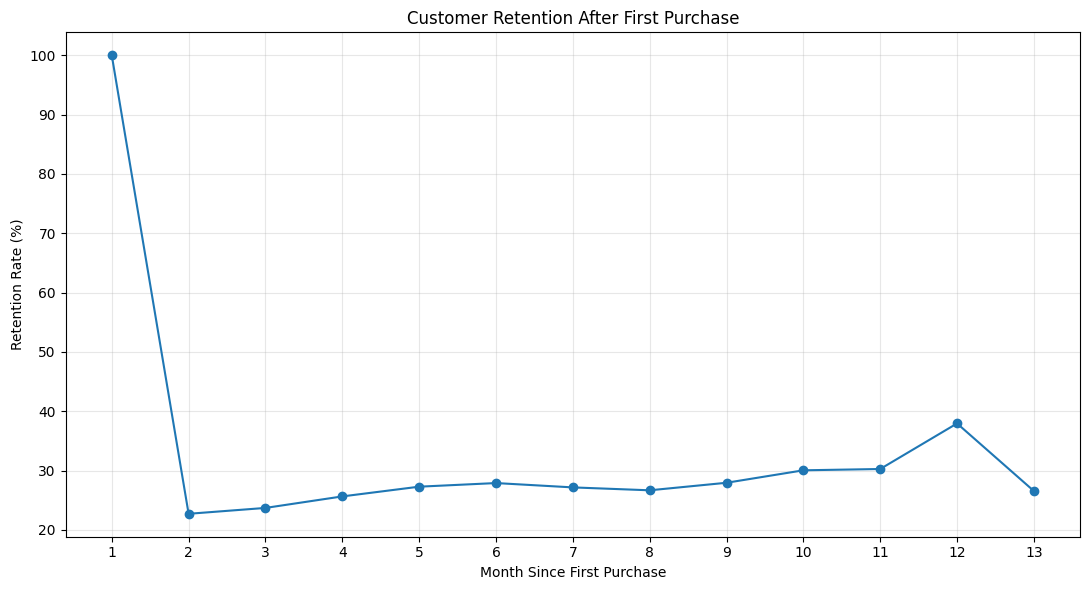

In [36]:
# STEP 33: COHORT RETENTION ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Prepare data
# -------------------------------------------------------

cohort_df = analysis_df.copy()

# Make sure InvoiceDate is datetime
cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])

# Keep rows with valid CustomerID
cohort_df = cohort_df.dropna(subset=["CustomerID"]).copy()

# -------------------------------------------------------
# 2. Create transaction month
# -------------------------------------------------------

cohort_df["InvoiceMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M")
)

# -------------------------------------------------------
# 3. Find each customer's first purchase month
# -------------------------------------------------------

cohort_df["CohortMonth"] = (
    cohort_df.groupby("CustomerID")["InvoiceDate"]
    .transform("min")
    .dt.to_period("M")
)

# -------------------------------------------------------
# 4. Calculate months since first purchase
# -------------------------------------------------------

cohort_df["CohortIndex"] = (
    (cohort_df["InvoiceMonth"].dt.year -
     cohort_df["CohortMonth"].dt.year) * 12
    +
    (cohort_df["InvoiceMonth"].dt.month -
     cohort_df["CohortMonth"].dt.month)
    + 1
)

# -------------------------------------------------------
# 5. Count unique customers in each cohort/month
# -------------------------------------------------------

cohort_counts = (
    cohort_df.groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)

# Pivot into cohort table
cohort_table = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

# -------------------------------------------------------
# 6. Calculate retention rates
# -------------------------------------------------------

cohort_sizes = cohort_table.iloc[:, 0]

retention_table = cohort_table.divide(
    cohort_sizes,
    axis=0
) * 100

# Round percentages
retention_table = retention_table.round(2)

print("COHORT RETENTION ANALYSIS")
print("-" * 70)

print("\nCustomer Counts by Cohort:")
display(cohort_table)

print("\nRetention Rate (%):")
display(retention_table)

# -------------------------------------------------------
# 7. Overall retention by months after first purchase
# -------------------------------------------------------

weighted_retention = []

for column in cohort_table.columns:

    available = cohort_table[column].dropna()

    if len(available) > 0:

        original_sizes = cohort_sizes.loc[available.index]

        retention = (
            available.sum()
            / original_sizes.sum()
            * 100
        )

        weighted_retention.append(
            [column, retention]
        )

overall_retention = pd.DataFrame(
    weighted_retention,
    columns=[
        "Month_Since_First_Purchase",
        "Retention_Rate"
    ]
)

overall_retention["Retention_Rate"] = (
    overall_retention["Retention_Rate"]
    .round(2)
)

print("\nOVERALL CUSTOMER RETENTION")
print("-" * 50)

display(overall_retention)

# -------------------------------------------------------
# 8. Plot overall retention
# -------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    overall_retention["Month_Since_First_Purchase"],
    overall_retention["Retention_Rate"],
    marker="o"
)

plt.title("Customer Retention After First Purchase")
plt.xlabel("Month Since First Purchase")
plt.ylabel("Retention Rate (%)")

plt.xticks(
    overall_retention["Month_Since_First_Purchase"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# STEP 34: EXECUTIVE BUSINESS SUMMARY

import pandas as pd

print("=" * 75)
print("                 EXECUTIVE BUSINESS SUMMARY")
print("=" * 75)

# -------------------------------------------------------
# 1. OVERALL BUSINESS PERFORMANCE
# -------------------------------------------------------

total_revenue = analysis_df["Revenue"].sum()

total_transactions = analysis_df["InvoiceNo"].nunique()

total_customers = analysis_df["CustomerID"].nunique()

total_units = analysis_df["Quantity"].sum()

print("\n1. OVERALL BUSINESS PERFORMANCE")
print("-" * 75)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Units Sold: {total_units:,.0f}")


# -------------------------------------------------------
# 2. CUSTOMER BEHAVIOR
# -------------------------------------------------------

customer_orders = (
    analysis_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

repeat_customers = customer_orders[
    customer_orders > 1
].index

repeat_revenue = analysis_df[
    analysis_df["CustomerID"].isin(repeat_customers)
]["Revenue"].sum()

repeat_customer_rate = (
    len(repeat_customers)
    / total_customers
    * 100
)

repeat_revenue_percentage = (
    repeat_revenue
    / total_revenue
    * 100
)

print("\n2. CUSTOMER BEHAVIOR")
print("-" * 75)

print(
    f"Repeat Customers: "
    f"{len(repeat_customers):,} "
    f"({repeat_customer_rate:.2f}% of customers)"
)

print(
    f"Revenue from Repeat Customers: "
    f"£{repeat_revenue:,.2f} "
    f"({repeat_revenue_percentage:.2f}% of revenue)"
)


# -------------------------------------------------------
# 3. TOP PRODUCT
# -------------------------------------------------------

product_summary = (
    analysis_df.groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

top_product = product_summary.loc[
    product_summary["Revenue"].idxmax()
]

print("\n3. TOP PRODUCT")
print("-" * 75)

print(f"Product: {top_product['Description']}")
print(f"Stock Code: {top_product['StockCode']}")
print(f"Units Sold: {top_product['Units_Sold']:,.0f}")
print(f"Revenue: £{top_product['Revenue']:,.2f}")


# -------------------------------------------------------
# 4. TOP MARKET
# -------------------------------------------------------

country_summary = (
    analysis_df.groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

top_country = country_summary.iloc[0]

print("\n4. TOP MARKET")
print("-" * 75)

print(f"Country: {top_country['Country']}")
print(f"Revenue: £{top_country['Revenue']:,.2f}")
print(f"Orders: {top_country['Orders']:,.0f}")


# -------------------------------------------------------
# 5. SALES TIMING
# -------------------------------------------------------

analysis_df["InvoiceDate"] = pd.to_datetime(
    analysis_df["InvoiceDate"]
)

analysis_df["Day_of_Week"] = (
    analysis_df["InvoiceDate"].dt.day_name()
)

analysis_df["Hour"] = (
    analysis_df["InvoiceDate"].dt.hour
)

day_revenue = (
    analysis_df.groupby("Day_of_Week")["Revenue"]
    .sum()
)

hour_revenue = (
    analysis_df.groupby("Hour")["Revenue"]
    .sum()
)

best_day = day_revenue.idxmax()
best_day_revenue = day_revenue.max()

best_hour = hour_revenue.idxmax()
best_hour_revenue = hour_revenue.max()

print("\n5. SALES TIMING")
print("-" * 75)

print(
    f"Highest Revenue Day: "
    f"{best_day} "
    f"(£{best_day_revenue:,.2f})"
)

print(
    f"Peak Revenue Hour: "
    f"{best_hour}:00 "
    f"(£{best_hour_revenue:,.2f})"
)


# -------------------------------------------------------
# 6. MONTHLY PERFORMANCE
# -------------------------------------------------------

monthly_summary = (
    analysis_df
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
    .reset_index()
)

monthly_summary["MoM_Growth"] = (
    monthly_summary["Revenue"]
    .pct_change()
    * 100
)

# Exclude final incomplete month when identifying
# strongest and weakest complete-month performance
complete_months = monthly_summary.iloc[:-1].copy()

highest_month = complete_months.loc[
    complete_months["Revenue"].idxmax()
]

growth_months = complete_months.dropna(
    subset=["MoM_Growth"]
)

strongest_growth = growth_months.loc[
    growth_months["MoM_Growth"].idxmax()
]

print("\n6. MONTHLY PERFORMANCE")
print("-" * 75)

print(
    f"Highest Complete Revenue Month: "
    f"{highest_month['InvoiceDate'].strftime('%Y-%m')} "
    f"(£{highest_month['Revenue']:,.2f})"
)

print(
    f"Strongest Month-over-Month Growth: "
    f"{strongest_growth['InvoiceDate'].strftime('%Y-%m')} "
    f"({strongest_growth['MoM_Growth']:.2f}%)"
)

print(
    "Note: Final December 2011 results represent "
    "an incomplete month and should not be directly "
    "compared with complete months."
)


# -------------------------------------------------------
# 7. CUSTOMER RETENTION
# -------------------------------------------------------

month_two_retention = overall_retention.loc[
    overall_retention[
        "Month_Since_First_Purchase"
    ] == 2,
    "Retention_Rate"
].iloc[0]

print("\n7. CUSTOMER RETENTION")
print("-" * 75)

print(
    f"Month 2 Retention Rate: "
    f"{month_two_retention:.2f}%"
)

print(
    "Retention drops substantially after the initial "
    "purchase month, making early repeat purchasing "
    "an important customer-retention opportunity."
)


# -------------------------------------------------------
# 8. BUSINESS RECOMMENDATIONS
# -------------------------------------------------------

print("\n8. BUSINESS RECOMMENDATIONS")
print("-" * 75)

print("""
1. RETAIN FIRST-TIME CUSTOMERS
   Introduce post-purchase campaigns, personalized
   recommendations, and incentives designed to encourage
   a second purchase.

2. PROTECT HIGH-VALUE REPEAT CUSTOMERS
   Repeat customers generate the large majority of revenue.
   Loyalty programs and targeted offers could help maintain
   these valuable relationships.

3. PRIORITIZE HIGH-VALUE CUSTOMER SEGMENTS
   Use RFM segmentation to target Champions and Loyal
   Customers with retention and loyalty campaigns while
   developing re-engagement strategies for At-Risk customers.

4. OPTIMIZE SALES TIMING
   Schedule major promotions and marketing activity around
   the strongest purchasing periods identified in the
   day-of-week and hourly sales analysis.

5. SUPPORT TOP-PERFORMING PRODUCTS
   Maintain inventory availability for high-revenue and
   high-volume products and consider related-product
   recommendations or bundles.

6. INVESTIGATE CUSTOMER CONCENTRATION
   A relatively small portion of customers contributes a
   substantial share of revenue. Protect these relationships
   while expanding revenue across the broader customer base.
""")


print("=" * 75)
print("                    END OF ANALYSIS")
print("=" * 75)

                 EXECUTIVE BUSINESS SUMMARY

1. OVERALL BUSINESS PERFORMANCE
---------------------------------------------------------------------------
Total Revenue: £8,887,208.89
Total Transactions: 18,532
Total Customers: 4,338
Total Units Sold: 5,152,002

2. CUSTOMER BEHAVIOR
---------------------------------------------------------------------------
Repeat Customers: 2,845 (65.58% of customers)
Revenue from Repeat Customers: £8,273,219.33 (93.09% of revenue)

3. TOP PRODUCT
---------------------------------------------------------------------------
Product: PAPER CRAFT , LITTLE BIRDIE
Stock Code: 23843
Units Sold: 80,995
Revenue: £168,469.60

4. TOP MARKET
---------------------------------------------------------------------------
Country: United Kingdom
Revenue: £7,285,024.64
Orders: 16,646

5. SALES TIMING
---------------------------------------------------------------------------
Highest Revenue Day: Thursday (£1,973,015.73)
Peak Revenue Hour: 12:00 (£1,373,695.39)

6. MONTHLY

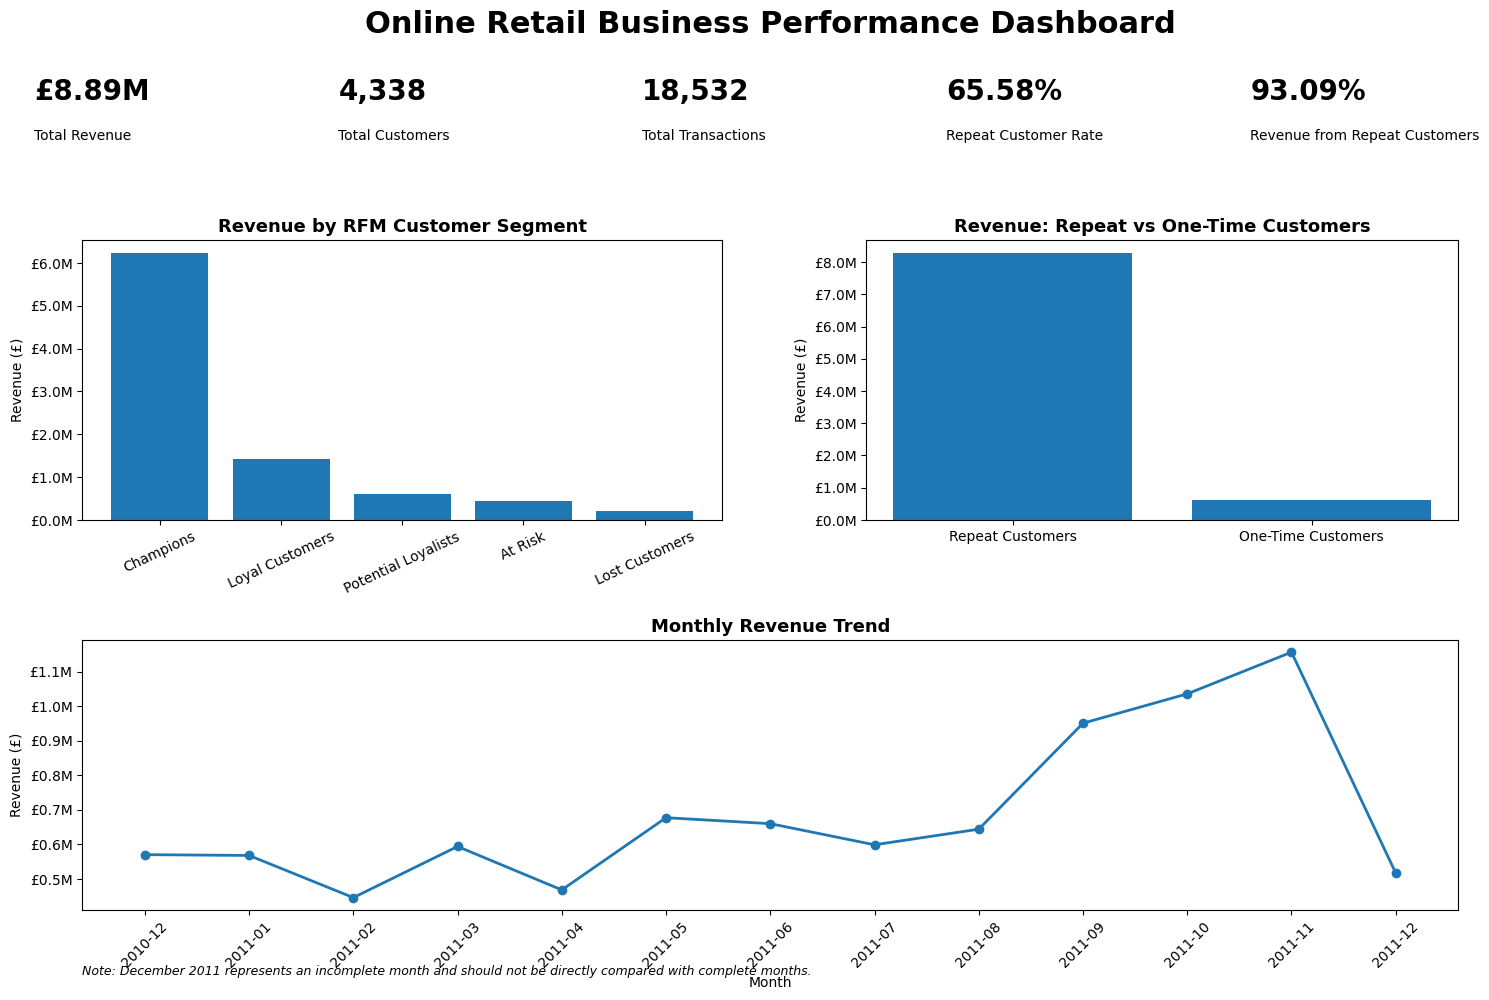

In [38]:
# STEP 35: PORTFOLIO KPI DASHBOARD

# ============================================================
# STEP 35: PORTFOLIO KPI DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------
# Key business metrics
# -----------------------------
total_revenue = 8887208.89
total_customers = 4338
total_transactions = 18532
repeat_rate = 65.58
repeat_revenue_pct = 93.09

# -----------------------------
# Create dashboard
# -----------------------------
fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "Online Retail Business Performance Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# KPI cards
kpis = [
    ("Total Revenue", f"£{total_revenue/1_000_000:.2f}M"),
    ("Total Customers", f"{total_customers:,}"),
    ("Total Transactions", f"{total_transactions:,}"),
    ("Repeat Customer Rate", f"{repeat_rate:.2f}%"),
    ("Revenue from Repeat Customers", f"{repeat_revenue_pct:.2f}%")
]

positions = [0.04, 0.23, 0.42, 0.61, 0.80]

for x, (label, value) in zip(positions, kpis):
    fig.text(
        x, 0.89, value,
        fontsize=20,
        fontweight="bold",
        ha="left"
    )

    fig.text(
        x, 0.85, label,
        fontsize=10,
        ha="left"
    )

# ============================================================
# CHART 1: Revenue by Customer Segment
# ============================================================

ax1 = fig.add_axes([0.07, 0.47, 0.40, 0.28])

segment_names = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Lost Customers"
]

segment_revenue = [
    6229304.44,
    1412579.34,
    610441.70,
    432825.89,
    202057.52
]

ax1.bar(segment_names, segment_revenue)

ax1.set_title(
    "Revenue by RFM Customer Segment",
    fontsize=13,
    fontweight="bold"
)

ax1.set_ylabel("Revenue (£)")
ax1.tick_params(axis="x", rotation=25)

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# ============================================================
# CHART 2: Repeat vs One-Time Revenue
# ============================================================

ax2 = fig.add_axes([0.56, 0.47, 0.37, 0.28])

customer_types = [
    "Repeat Customers",
    "One-Time Customers"
]

customer_revenue = [
    8273219.33,
    613989.56
]

ax2.bar(customer_types, customer_revenue)

ax2.set_title(
    "Revenue: Repeat vs One-Time Customers",
    fontsize=13,
    fontweight="bold"
)

ax2.set_ylabel("Revenue (£)")

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# ============================================================
# CHART 3: Monthly Revenue Trend
# ============================================================

ax3 = fig.add_axes([0.07, 0.08, 0.86, 0.27])

months = [
    "2010-12", "2011-01", "2011-02", "2011-03",
    "2011-04", "2011-05", "2011-06", "2011-07",
    "2011-08", "2011-09", "2011-10", "2011-11",
    "2011-12"
]

monthly_revenue = [
    570422.73,
    568101.31,
    446084.92,
    594081.76,
    468374.33,
    677355.15,
    660046.05,
    598962.90,
    644051.04,
    950690.20,
    1035642.45,
    1156205.61,
    517190.44
]

ax3.plot(
    months,
    monthly_revenue,
    marker="o",
    linewidth=2
)

ax3.set_title(
    "Monthly Revenue Trend",
    fontsize=13,
    fontweight="bold"
)

ax3.set_ylabel("Revenue (£)")
ax3.set_xlabel("Month")

ax3.tick_params(
    axis="x",
    rotation=45
)

ax3.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# Important note about incomplete December
fig.text(
    0.07,
    0.015,
    "Note: December 2011 represents an incomplete month and should not be directly compared with complete months.",
    fontsize=9,
    style="italic"
)

plt.show()

In [39]:
# Project Conclusion

## Overview

# This project analyzed an online retail transaction dataset to identify customer purchasing patterns, revenue drivers, customer segments, retention behavior, and opportunities for business growth.

# Using Python and pandas, the analysis transformed raw transaction data into actionable business insights through exploratory data analysis, customer segmentation, revenue analysis, and retention analysis.

## Key Findings

# - **£8.89 million** in total revenue was analyzed across **18,532 transactions** and **4,338 customers**.
# - **65.58% of customers were repeat customers**, generating **93.09% of total revenue**.
# - RFM segmentation identified **Champions** as the highest-value customer segment, generating approximately **£6.23 million** in revenue.
# - Customer retention dropped to **22.71% in the second month after the initial purchase**, highlighting an opportunity to improve early customer retention.
# - The **United Kingdom** was the largest market, generating approximately **£7.29 million** in revenue.
# - The highest complete monthly revenue occurred in **November 2011**, reaching approximately **£1.16 million**.
# - Revenue was strongest around the middle of the day, with **12:00 PM** producing the highest hourly revenue.
# - Revenue was highly concentrated among the highest-value customers.

## Business Recommendations

# 1. Develop post-purchase campaigns to encourage first-time customers to make a second purchase.
# 2. Use loyalty programs and personalized offers to retain high-value repeat customers.
# 3. Prioritize Champions and Loyal Customers identified through RFM segmentation.
# 4. Develop re-engagement campaigns for At-Risk customers.
# 5. Schedule promotions around high-performing purchasing periods.
# 6. Maintain inventory availability for top-performing products.
# 7. Reduce dependence on a relatively small group of high-value customers by increasing engagement across the broader customer base.

## Tools & Techniques

# - Python
# - pandas
# - NumPy
# - Matplotlib
# - Data Cleaning
# - Exploratory Data Analysis (EDA)
# - RFM Customer Segmentation
# - Customer Retention Analysis
# - Revenue Concentration Analysis
# - Time-Series Analysis
# - Business KPI Development
# - Data Visualization

## Conclusion

# The analysis demonstrates that repeat customers and high-value customer segments are major drivers of business performance. The strongest opportunity is to improve the conversion of first-time customers into repeat purchasers while maintaining relationships with existing high-value customers.

# The findings provide a data-driven foundation for customer retention, targeted marketing, inventory planning, and revenue growth strategies.